Mounted at /content/drive
RUN SUMMARY: model_pretrained_250k_ingfirst

CONFIG
  run_name             250k_ingfirst
  base_model           gpt2
  sample_size          250000
  num_epochs           2
  learning_rate        5e-05
  max_length           512
  train_batch_size     8
  grad_accum_steps     4

TRAINING DYNAMICS
  train points         74
  steps                200 -> 14800
  first / final loss   3.0614 -> 1.8250
  eval points          30
  first eval loss      2.3124  (ppl 10.099)
  final eval loss      1.7770  (ppl 5.912)

GENERATION METRICS (ingredients -> title + directions)
  ROUGE-1              0.3209
  ROUGE-2              0.0907
  ROUGE-L              0.2165
  BLEU-4               0.0493
  Ingredient coverage  59.31%
  Eval samples         50




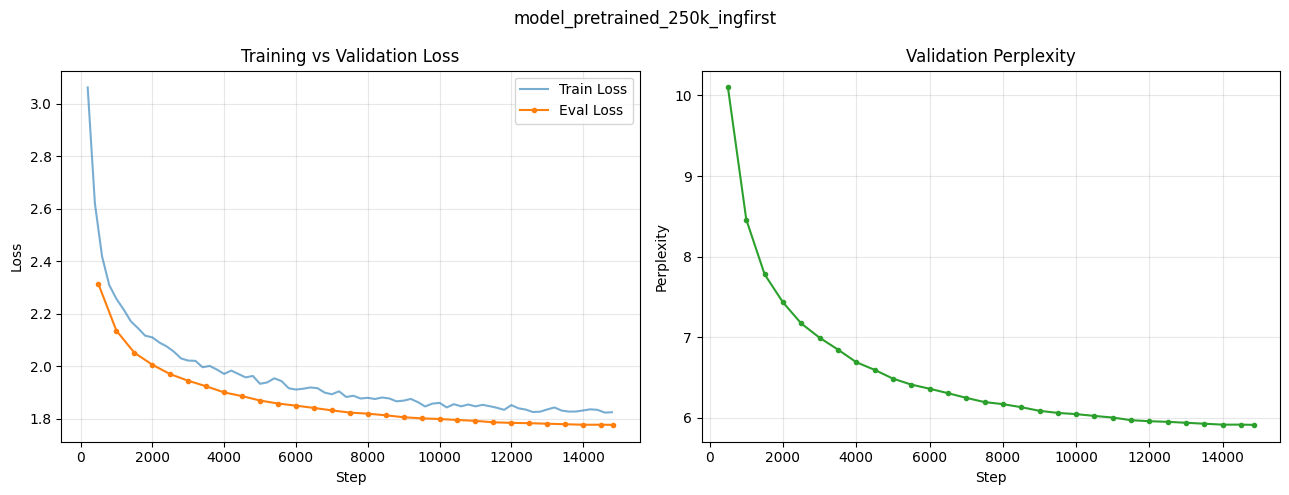

In [1]:
import os, csv, json, math
import matplotlib.pyplot as plt
from google.colab import drive

if not os.path.ismount("/content/drive"):
    drive.mount("/content/drive")

MODEL_DIR = "/content/drive/MyDrive/recipe_gpt2/model_pretrained_250k_ingfirst"

def _num(v):
    try: return float(v)
    except (TypeError, ValueError): return None

# pull in the the training history, that tracks the losses by steps
train, evals = [], []
csv_path = os.path.join(MODEL_DIR, "training_history.csv")
for row in csv.DictReader(open(csv_path)):
    step = _num(row.get("step"))
    if step is None: continue
    step = int(step)
    loss = _num(row.get("loss"))
    if loss is not None:
        train.append((step, loss))
    el = _num(row.get("eval_loss"))
    if el is not None:
        ppl = _num(row.get("eval_perplexity")) or (math.exp(el) if el < 20 else float("inf"))
        evals.append((step, el, ppl))

# pull in the summary data
summary = {}
sp = os.path.join(MODEL_DIR, "training_summary.json")
summary = json.load(open(sp))

# pretty print the results so they look presentable
print("RUN SUMMARY:", os.path.basename(MODEL_DIR.rstrip("/")))

cfg = summary.get("config", {})
if cfg:
    print("\nCONFIG")
    for k, v in cfg.items(): print(f"  {k:<20} {v}")

print("\nTRAINING DYNAMICS")
if train:
    print(f"  train points         {len(train)}")
    print(f"  steps                {train[0][0]} -> {train[-1][0]}")
    print(f"  first / final loss   {train[0][1]:.4f} -> {train[-1][1]:.4f}")
if evals:
    best, final = min(evals, key=lambda p: p[1]), evals[-1]
    print(f"  eval points          {len(evals)}")
    print(f"  first eval loss      {evals[0][1]:.4f}  (ppl {evals[0][2]:.3f})")
    print(f"  final eval loss      {final[1]:.4f}  (ppl {final[2]:.3f})")

m = summary.get("generation_metrics", {})
print("\nGENERATION METRICS (ingredients -> title + directions)")
for k, lbl in [("rouge1","ROUGE-1"),("rouge2","ROUGE-2"),("rougeL","ROUGE-L"),
                ("bleu4","BLEU-4"),("ingredient_coverage","Ingredient coverage"),
                ("num_eval_samples","Eval samples")]:
    if k not in m: continue
    v = m[k]
    if k == "ingredient_coverage": print(f"  {lbl:<20} {v*100:.2f}%")
    elif k == "num_eval_samples":  print(f"  {lbl:<20} {int(v)}")
    else:                          print(f"  {lbl:<20} {v:.4f}")

print("\n")

# draw the plots
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
if train: a1.plot([p[0] for p in train], [p[1] for p in train], alpha=0.6, label="Train Loss")
if evals: a1.plot([p[0] for p in evals], [p[1] for p in evals], marker="o", ms=3, label="Eval Loss")
a1.set_xlabel("Step"); a1.set_ylabel("Loss"); a1.set_title("Training vs Validation Loss")
a1.legend(); a1.grid(alpha=0.3)
if evals:
    a2.plot([p[0] for p in evals], [p[2] for p in evals], marker="o", ms=3, color="tab:green")
    b = min(evals, key=lambda p: p[1])
a2.set_xlabel("Step"); a2.set_ylabel("Perplexity"); a2.set_title("Validation Perplexity")
a2.grid(alpha=0.3)
fig.suptitle(os.path.basename(MODEL_DIR.rstrip("/"))); fig.tight_layout()
plt.show()